Imports

In [9]:
# Importa a biblioteca Joblib para carregar os dados preparados e salvar os modelos treinados.
import joblib

# Importa o classificador Logistic Regression.
from sklearn.linear_model import LogisticRegression

# Importa o classificador Multinomial Naive Bayes.
from sklearn.naive_bayes import MultinomialNB

# Importa o classificador Support Vector Machine.
from sklearn.svm import LinearSVC

# Importa o classificador Random Forest.
from sklearn.ensemble import RandomForestClassifier

| Modelo                      | Característica                                  |
| --------------------------- | ----------------------------------------------- |
| **Logistic Regression**     | Excelente modelo de baseline para classificação |
| **Multinomial Naive Bayes** | Muito utilizado em classificação de textos      |
| **Linear SVC**              | Bom desempenho com dados de texto e TF-IDF      |
| **Random Forest**           | Captura relações mais complexas entre features  |


Carregar os dados preparados

In [10]:
# Importa a biblioteca Joblib para carregar arquivos salvos no formato Joblib.
import joblib

# Carrega o arquivo contendo todos os dados preparados anteriormente.
dados_preparados = joblib.load("../data/processed/dados_preparados.joblib")

# Exibe os nomes das informações armazenadas no arquivo.
print(dados_preparados.keys())

dict_keys(['X_treino_final', 'X_teste_final', 'y_treino', 'y_teste', 'vetorizador_tfidf', 'nomes_features'])


Recuperar as variáveis

In [11]:
# Recupera os dados finais de treinamento contendo TF-IDF e features estruturadas.
X_treino_final = dados_preparados["X_treino_final"]

# Recupera os dados finais de teste contendo TF-IDF e features estruturadas.
X_teste_final = dados_preparados["X_teste_final"]

# Recupera os valores da variável-alvo utilizados durante o treinamento.
y_treino = dados_preparados["y_treino"]

# Recupera os valores reais da variável-alvo utilizados posteriormente nos testes.
y_teste = dados_preparados["y_teste"]

# Recupera o vetorizador TF-IDF utilizado durante a preparação das mensagens.
vetorizador_tfidf = dados_preparados["vetorizador_tfidf"]

# Recupera os nomes das features estruturadas utilizadas no modelo.
nomes_features = dados_preparados["nomes_features"]

Conferir os dados

In [12]:
# Exibe o formato da matriz final utilizada para treinamento.
print("Formato de X_treino_final:", X_treino_final.shape)

# Exibe o formato da matriz final utilizada para teste.
print("Formato de X_teste_final:", X_teste_final.shape)

# Exibe a quantidade de classificações utilizadas no treinamento.
print("Formato de y_treino:", y_treino.shape)

# Exibe a quantidade de classificações utilizadas no teste.
print("Formato de y_teste:", y_teste.shape)

# Exibe a quantidade de features estruturadas.
print("Quantidade de features estruturadas:", len(nomes_features))

Formato de X_treino_final: (1077, 2875)
Formato de X_teste_final: (270, 2875)
Formato de y_treino: (1077,)
Formato de y_teste: (270,)
Quantidade de features estruturadas: 2875


Verificar o balanceamento do treino e teste

In [13]:
# Conta quantas mensagens de cada classe existem no conjunto de treinamento.
print("Distribuição do y_treino:")

# Exibe a quantidade de mensagens classificadas como não golpe e possível golpe no treinamento.
print(y_treino.value_counts())

# Cria uma linha em branco para melhorar a visualização da saída.
print()

# Conta quantas mensagens de cada classe existem no conjunto de teste.
print("Distribuição do y_teste:")

# Exibe a quantidade de mensagens classificadas como não golpe e possível golpe no teste.
print(y_teste.value_counts())

Distribuição do y_treino:
possivel_golpe
0    666
1    411
Name: count, dtype: int64

Distribuição do y_teste:
possivel_golpe
0    167
1    103
Name: count, dtype: int64


TREINAR Logistic Regression

In [14]:
# Cria o modelo de Regressão Logística para classificar as mensagens.
modelo_logistic_regression = LogisticRegression(
    
    # Define um limite maior de iterações para permitir que o modelo encontre uma solução adequada.
    max_iter=1000,
    
    # Define uma semente para tornar o treinamento reproduzível.
    random_state=42
)

# Treina o modelo utilizando as características finais e as classificações do conjunto de treinamento.
modelo_logistic_regression.fit(X_treino_final, y_treino)

# Exibe uma mensagem confirmando que o treinamento foi concluído.
print("Modelo Logistic Regression treinado com sucesso.")

Modelo Logistic Regression treinado com sucesso.


X_treino_final
      +
y_treino
      ↓
  Logistic Regression
      ↓
Aprende padrões
      ↓
modelo_logistic_regression

TREINAR Multinomial Naive Bayes

In [15]:
# Cria o modelo Multinomial Naive Bayes para classificação das mensagens.
modelo_naive_bayes = MultinomialNB()

In [16]:
# Treina o modelo utilizando as características finais e as classificações do conjunto de treinamento.
modelo_naive_bayes.fit(X_treino_final, y_treino)

# Exibe uma mensagem confirmando que o treinamento foi concluído.
print("Modelo Multinomial Naive Bayes treinado com sucesso.")

Modelo Multinomial Naive Bayes treinado com sucesso.


TREINAR LinearSVC

In [17]:
# Importa o método utilizado para transformar as pontuações do LinearSVC em probabilidades.
from sklearn.calibration import CalibratedClassifierCV

In [18]:
# Cria o LinearSVC que será utilizado como classificador base.
modelo_linear_svc_base = LinearSVC(
    
    # Define uma semente para tornar o treinamento reproduzível.
    random_state=42
)

In [19]:
# Cria o LinearSVC calibrado para permitir a utilização do predict_proba().
modelo_linear_svc = CalibratedClassifierCV(
    
    # Informa o LinearSVC que será calibrado.
    estimator=modelo_linear_svc_base,
    
    # Divide os dados de treinamento em cinco partes para realizar a calibração.
    cv=5
)

# Treina o LinearSVC calibrado utilizando somente os 80% de treinamento.
modelo_linear_svc.fit(X_treino_final, y_treino)

# Exibe uma mensagem confirmando que o treinamento foi concluído.
print("Modelo LinearSVC treinado com sucesso.")

Modelo LinearSVC treinado com sucesso.


TREINAR Random Forest

In [20]:
# Cria o modelo Random Forest para classificação das mensagens.
modelo_random_forest = RandomForestClassifier(
    
    # Define a quantidade de árvores que serão utilizadas pelo modelo.
    n_estimators=200,
    
    # Define uma semente para tornar os resultados reproduzíveis.
    random_state=42,
    
    # Permite utilizar todos os núcleos disponíveis do computador durante o treinamento.
    n_jobs=-1
)

In [21]:
# Treina o modelo utilizando as características finais e as classificações do conjunto de treinamento.
modelo_random_forest.fit(X_treino_final, y_treino)

# Exibe uma mensagem confirmando que o treinamento foi concluído.
print("Modelo Random Forest treinado com sucesso.")

Modelo Random Forest treinado com sucesso.


TREINAR XGBOOST

In [22]:
# Importa o classificador XGBoost para treinamento do modelo.
from xgboost import XGBClassifier

In [23]:
# Importa o classificador XGBoost para classificação binária.
from xgboost import XGBClassifier

# Cria o modelo XGBoost.
modelo_xgboost = XGBClassifier(
    # Define a quantidade de árvores utilizadas pelo modelo.
    n_estimators=200,

    # Define a profundidade máxima das árvores.
    max_depth=6,

    # Define a taxa de aprendizado utilizada pelo modelo.
    learning_rate=0.1,

    # Define a métrica utilizada durante o treinamento.
    eval_metric="logloss",

    # Define uma semente para garantir resultados reproduzíveis.
    random_state=42,

    # Permite utilizar todos os núcleos disponíveis do processador.
    n_jobs=-1
)

# Treina o XGBoost utilizando os dados de treinamento.
modelo_xgboost.fit(
    X_treino_final,
    y_treino
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Gerar as previsões (TESTE com os 20% separados)

In [36]:
# Calcula as probabilidades das duas classes para as mensagens do conjunto de teste usando Logistic Regression.
probabilidades_logistic_regression = modelo_logistic_regression.predict_proba(X_teste_final)

# Calcula as probabilidades das duas classes para as mensagens do conjunto de teste usando Naive Bayes.
probabilidades_naive_bayes = modelo_naive_bayes.predict_proba(X_teste_final)

# Calcula as probabilidades das duas classes para as mensagens do conjunto de teste usando LinearSVC calibrado.
probabilidades_linear_svc = modelo_linear_svc.predict_proba(X_teste_final)

# Calcula as probabilidades das duas classes para as mensagens do conjunto de teste usando Random Forest.
probabilidades_random_forest = modelo_random_forest.predict_proba(X_teste_final)

# Calcula as probabilidades das duas classes para as mensagens de teste.
probabilidades_xgboost = modelo_xgboost.predict_proba(X_teste_final)



Extrair somente a probabilidade de possível golpe

In [37]:
# Obtém a probabilidade da classe 1 para cada mensagem utilizando Logistic Regression.
probabilidade_golpe_logistic = probabilidades_logistic_regression[:, 1]

# Obtém a probabilidade da classe 1 para cada mensagem utilizando Naive Bayes.
probabilidade_golpe_naive_bayes = probabilidades_naive_bayes[:, 1]

# Obtém a probabilidade da classe 1 para cada mensagem utilizando LinearSVC calibrado.
probabilidade_golpe_linear_svc = probabilidades_linear_svc[:, 1]

# Obtém a probabilidade da classe 1 para cada mensagem utilizando Random Forest.
probabilidade_golpe_random_forest = probabilidades_random_forest[:, 1]

# Seleciona somente a probabilidade da classe 1, que representa possível golpe.
probabilidade_xgboost_golpe = probabilidades_xgboost[:, 1]

Criar uma tabela para comparar os modelos

In [26]:
# Importa a biblioteca Pandas para criação e manipulação de DataFrames.
import pandas as pd

In [38]:
# Cria um DataFrame para comparar a classificação real com as probabilidades dos cinco modelos.
resultado_probabilidades = pd.DataFrame({
    
    # Armazena a classificação real das mensagens do conjunto de teste.
    "real": y_teste.values,
    
    # Armazena a probabilidade de possível golpe calculada pelo Logistic Regression.
    "logistic_regression": probabilidade_golpe_logistic,
    
    # Armazena a probabilidade de possível golpe calculada pelo Naive Bayes.
    "naive_bayes": probabilidade_golpe_naive_bayes,
    
    # Armazena a probabilidade de possível golpe calculada pelo LinearSVC calibrado.
    "linear_svc": probabilidade_golpe_linear_svc,
    
    # Armazena a probabilidade de possível golpe calculada pelo Random Forest.
    "random_forest": probabilidade_golpe_random_forest,
    
    # Armazena a probabilidade de possível golpe calculada pelo XGBoost.
    "xgboost": probabilidade_xgboost_golpe
})

# Exibe as dez primeiras mensagens do conjunto de teste com as probabilidades estimadas pelos cinco modelos.
resultado_probabilidades.head(10)

,real,logistic_regression,naive_bayes,linear_svc,random_forest,xgboost
0,0,0.009652,0.003558,0.013901,0.000,0.001459
1,1,0.981470,0.999800,0.990244,0.945,0.995417
2,0,0.006632,0.005938,0.001424,0.075,0.007246
3,0,0.009350,0.001660,0.004197,0.095,0.016857
4,1,0.958265,1.000000,0.979948,0.925,0.992853
5,0,0.003991,0.042049,0.002218,0.015,0.000170
6,1,0.998110,1.000000,0.998893,0.950,0.998197
7,0,0.019656,0.308293,0.043145,0.105,0.000560
8,1,0.997101,1.000000,0.997882,0.995,0.999495
9,1,0.286603,0.926400,0.473923,0.525,0.692792


Nosso pipeline está assim:

Dataset
   ↓
Limpeza
   ↓
Separação 80% / 20%
   ↓
TF-IDF
   ↓
Features estruturadas
   ↓
Combinação das features
   ↓
Treinamento dos 4 modelos
   ↓
20% de teste
   ↓
predict_proba()
   ↓
Probabilidade de possível golpe ✅

Gráfico Classificação real × probabilidade estimada de possível golpe

In [39]:
# Importa a biblioteca os para trabalhar com pastas e caminhos de arquivos.
import os

# Define o caminho principal onde os gráficos do projeto serão armazenados.
pasta_graficos = "../reports/figures"

# Define o caminho da pasta destinada aos gráficos de avaliação dos modelos.
pasta_avaliacao = f"{pasta_graficos}/avaliacao_modelos"

# Cria a pasta de avaliação caso ela ainda não exista.
os.makedirs(pasta_avaliacao, exist_ok=True)

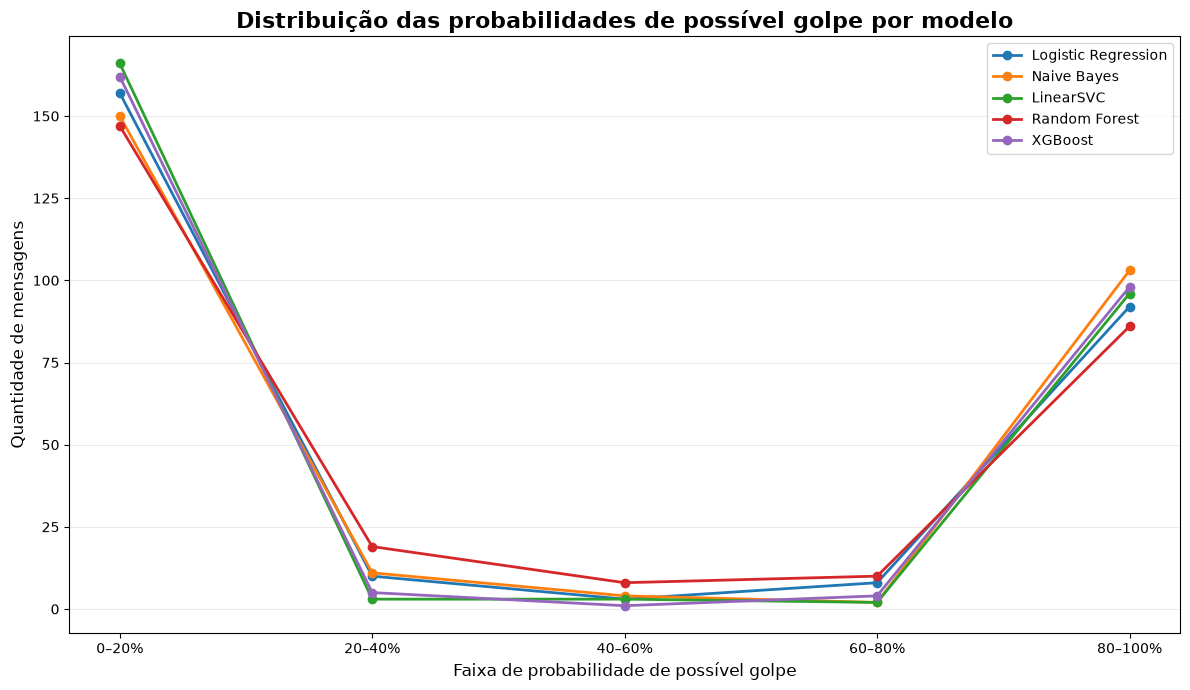

In [42]:
# Importa a biblioteca Matplotlib para criação dos gráficos.
import matplotlib.pyplot as plt

# Define as faixas de probabilidade que serão utilizadas no gráfico.
faixas_probabilidade = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Define os nomes que serão apresentados para cada faixa de probabilidade.
nomes_faixas = [
    "0–20%",
    "20–40%",
    "40–60%",
    "60–80%",
    "80–100%"
]

# Define os nomes das colunas que possuem as probabilidades dos cinco modelos.
modelos = [
    "logistic_regression",
    "naive_bayes",
    "linear_svc",
    "random_forest",
    "xgboost"
]

# Define os nomes amigáveis dos cinco modelos para apresentação no gráfico.
nomes_modelos = [
    "Logistic Regression",
    "Naive Bayes",
    "LinearSVC",
    "Random Forest",
    "XGBoost"
]

# Cria uma figura para apresentar a distribuição das probabilidades.
plt.figure(figsize=(12, 7))

# Percorre os cinco modelos para calcular sua distribuição de probabilidades.
for modelo, nome_modelo in zip(modelos, nomes_modelos):

    # Divide as probabilidades do modelo nas cinco faixas definidas anteriormente.
    distribuicao = pd.cut(
        resultado_probabilidades[modelo],
        bins=faixas_probabilidade,
        labels=nomes_faixas,
        include_lowest=True
    ).value_counts().sort_index()

    # Cria uma linha contendo a quantidade de mensagens em cada faixa de probabilidade.
    plt.plot(
        nomes_faixas,
        distribuicao.values,
        marker="o",
        linewidth=2,
        label=nome_modelo
    )

# Define o título do gráfico.
plt.title(
    "Distribuição das probabilidades de possível golpe por modelo",
    fontsize=16,
    fontweight="bold"
)

# Define o nome do eixo horizontal.
plt.xlabel(
    "Faixa de probabilidade de possível golpe",
    fontsize=12
)

# Define o nome do eixo vertical.
plt.ylabel(
    "Quantidade de mensagens",
    fontsize=12
)

# Exibe a legenda identificando os cinco modelos.
plt.legend()

# Adiciona linhas horizontais suaves para facilitar a comparação.
plt.grid(axis="y", alpha=0.25)

# Ajusta automaticamente os elementos do gráfico.
plt.tight_layout()

# Salva o gráfico na pasta de avaliação dos modelos.
plt.savefig(
    f"{pasta_avaliacao}/distribuicao_probabilidades_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico no notebook.
plt.show()

In [43]:
# Importa a biblioteca Matplotlib para criação do gráfico.
import matplotlib.pyplot as plt

# Define os nomes das colunas que possuem as probabilidades dos cinco modelos.
modelos = [
    "logistic_regression",
    "naive_bayes",
    "linear_svc",
    "random_forest",
    "xgboost"
]

# Define os nomes que serão apresentados no gráfico.
nomes_modelos = [
    "Logistic Regression",
    "Naive Bayes",
    "LinearSVC",
    "Random Forest",
    "XGBoost"
]

# Cria uma lista vazia para armazenar os resultados de cada modelo.
resultados_modelos = []

# Percorre cada modelo para calcular suas classificações.
for modelo in modelos:

    # Converte a probabilidade em uma classificação utilizando 50% como limite.
    classificacao_predita = (resultado_probabilidades[modelo] >= 0.5).astype(int)

    # Calcula a quantidade de Verdadeiros Negativos.
    verdadeiro_negativo = ((resultado_probabilidades["real"] == 0) & (classificacao_predita == 0)).sum()

    # Calcula a quantidade de Falsos Positivos.
    falso_positivo = ((resultado_probabilidades["real"] == 0) & (classificacao_predita == 1)).sum()

    # Calcula a quantidade de Falsos Negativos.
    falso_negativo = ((resultado_probabilidades["real"] == 1) & (classificacao_predita == 0)).sum()

    # Calcula a quantidade de Verdadeiros Positivos.
    verdadeiro_positivo = ((resultado_probabilidades["real"] == 1) & (classificacao_predita == 1)).sum()

    # Adiciona os quatro resultados do modelo à lista.
    resultados_modelos.append([
        verdadeiro_negativo,
        falso_positivo,
        falso_negativo,
        verdadeiro_positivo
    ])

# Converte os resultados calculados para um DataFrame.
df_resultados_modelos = pd.DataFrame(
    resultados_modelos,
    columns=["TN", "FP", "FN", "TP"],
    index=nomes_modelos
)

# Exibe a tabela com os resultados calculados.
df_resultados_modelos

,TN,FP,FN,TP
Logistic Regression,163,4,7,96
Naive Bayes,161,6,4,99
LinearSVC,164,3,6,97
Random Forest,166,1,5,98
XGBoost,164,3,4,99


In [44]:
# Importa a biblioteca NumPy para realizar operações numéricas.
import numpy as np

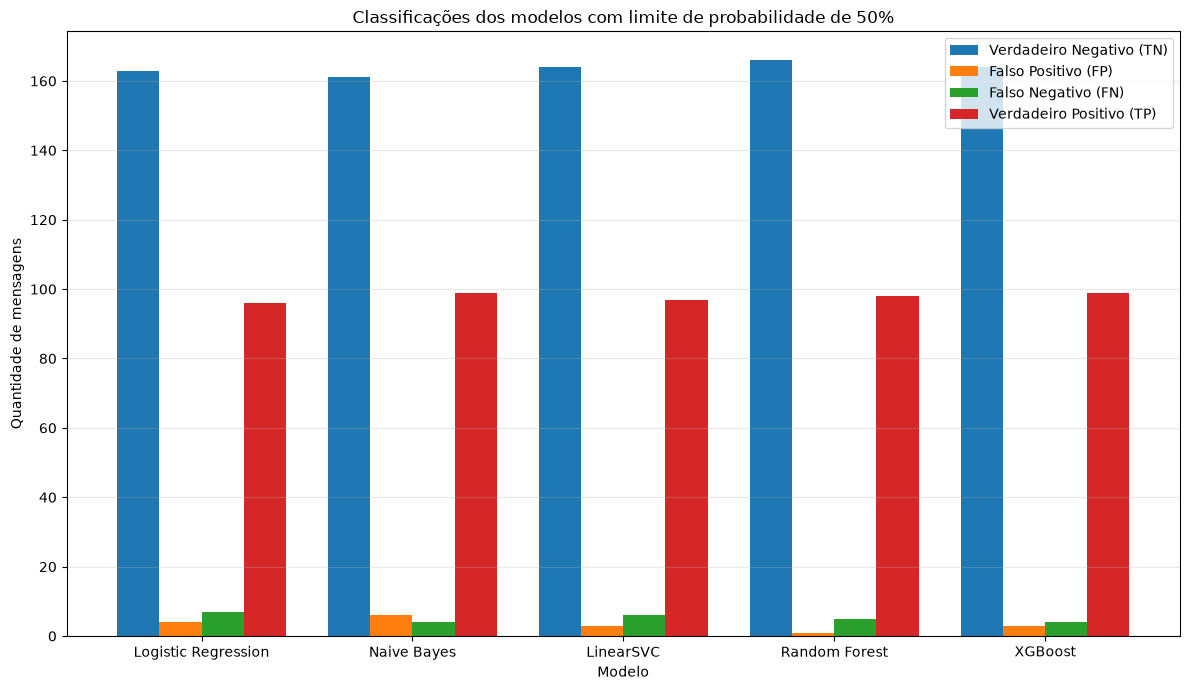

In [45]:
# Define a posição de cada modelo no eixo horizontal.
posicoes = np.arange(len(nomes_modelos))

# Define a largura de cada barra dentro de cada grupo.
largura_barra = 0.2

# Cria a figura que receberá o gráfico.
plt.figure(figsize=(12, 7))

# Cria as barras de Verdadeiros Negativos.
plt.bar(
    posicoes - 1.5 * largura_barra,
    df_resultados_modelos["TN"],
    largura_barra,
    label="Verdadeiro Negativo (TN)"
)

# Cria as barras de Falsos Positivos.
plt.bar(
    posicoes - 0.5 * largura_barra,
    df_resultados_modelos["FP"],
    largura_barra,
    label="Falso Positivo (FP)"
)

# Cria as barras de Falsos Negativos.
plt.bar(
    posicoes + 0.5 * largura_barra,
    df_resultados_modelos["FN"],
    largura_barra,
    label="Falso Negativo (FN)"
)

# Cria as barras de Verdadeiros Positivos.
plt.bar(
    posicoes + 1.5 * largura_barra,
    df_resultados_modelos["TP"],
    largura_barra,
    label="Verdadeiro Positivo (TP)"
)

# Define os nomes dos cinco modelos no eixo horizontal.
plt.xticks(posicoes, nomes_modelos)

# Define o nome do eixo horizontal.
plt.xlabel("Modelo")

# Define o nome do eixo vertical.
plt.ylabel("Quantidade de mensagens")

# Define o título do gráfico.
plt.title(
    "Classificações dos modelos com limite de probabilidade de 50%"
)

# Exibe a legenda explicando cada tipo de classificação.
plt.legend()

# Adiciona uma grade horizontal para facilitar a leitura dos valores.
plt.grid(axis="y", alpha=0.3)

# Ajusta automaticamente os elementos do gráfico para evitar sobreposição.
plt.tight_layout()

# Salva o gráfico na pasta destinada à avaliação dos modelos.
plt.savefig(
    f"{pasta_avaliacao}/classificacoes_modelos_50_porcento.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico.
plt.show()

Salvar resultados

In [48]:
# Importa a biblioteca Joblib para salvar os modelos treinados em arquivos.
import joblib

# Salva o modelo Logistic Regression treinado na pasta de modelos do projeto.
joblib.dump(
    modelo_logistic_regression,
    "../models/modelo_logistic_regression.joblib"
)

# Salva o modelo Naive Bayes treinado na pasta de modelos do projeto.
joblib.dump(
    modelo_naive_bayes,
    "../models/modelo_naive_bayes.joblib"
)

# Salva o modelo LinearSVC calibrado treinado na pasta de modelos do projeto.
joblib.dump(
    modelo_linear_svc,
    "../models/modelo_linear_svc.joblib"
)

# Salva o modelo Random Forest treinado na pasta de modelos do projeto.
joblib.dump(
    modelo_random_forest,
    "../models/modelo_random_forest.joblib"
)

# Salva o modelo XGBoost treinado na pasta de modelos do projeto.
joblib.dump(
    modelo_xgboost,
    "../models/modelo_xgboost.joblib"
)

['../models/modelo_xgboost.joblib']